In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [2]:
import pandas as pd

In [3]:
df1 = pd.read_excel(r"C:\Users\Dr Mutyala Balaji\Desktop\pap gypsum\PAP 02 gypsym loss prediction after ATA FY 26-27_1st part.xlsx")
df2 = pd.read_excel(r"C:\Users\Dr Mutyala Balaji\Desktop\pap gypsum\PAP 02 gypsym loss prediction after ATA FY 26-27_2nd part.xlsx")

In [4]:
df = pd.concat([df1, df2], ignore_index=True)

print("Combined Shape:", df.shape)

Combined Shape: (43206, 29)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43206 entries, 0 to 43205
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          43201 non-null  datetime64[ns]
 1   Slurry Flow                   43201 non-null  object        
 2   Slurry SpG                    43201 non-null  object        
 3   Cake Wash Flow                43201 non-null  object        
 4   Weak Wash  Flow               43202 non-null  object        
 5   Strong Wash flow              43201 non-null  object        
 6   HBF Vac Pump Amps             43201 non-null  object        
 7   HBF Vac                       43201 non-null  object        
 8   HBF Current                   43201 non-null  object        
 9   HBF Speed                     43201 non-null  object        
 10  HBF Air Support               43201 non-null  object        
 11  Filtrate SpG                

In [6]:
# Create copy
df_clean = df.copy()

# Find all object columns
object_cols = df_clean.select_dtypes(include='object').columns

print("Object Columns:")
print(object_cols)

# Convert object columns to numeric
for col in object_cols:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors='coerce'
    )

# Check result
print(df_clean.dtypes)

Object Columns:
Index(['Slurry Flow          ', 'Slurry SpG           ',
       'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow',
       'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ',
       'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ',
       'Solids%            ', 'Free Acid%        ', 'Return Acid         ',
       'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ',
       'Sulfuric acid  flow         ', 'LLFC Temp           ',
       'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ',
       'C Agitator  amps       ', 'D Agitator  amps        ',
       'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput'],
      dtype='object')
Date                            datetime64[ns]
Slurry Flow                            float64
Slurry SpG                             float64
Cake Wash Flow                         float64
Weak Wash  Flow                        float64
Strong Wash flow        

In [7]:
print(df_clean.dtypes.value_counts())

float64           28
datetime64[ns]     1
Name: count, dtype: int64


In [8]:
print(df_clean.isnull().sum().sort_values(ascending=False))

HBF Current                     669
HBF Speed                       669
Free Acid%                      234
Slurry SpG                      233
Filtrate SpG                    113
C Agitator  amps                 36
D Agitator  amps                 36
HBF Vac Pump Amps                10
Sulfuric acid  flow               9
HBF Vac                           8
Weak Wash  Flow                   8
Slurry Flow                       8
Cake Wash Flow                    8
LLFC Temp                         8
Rock  tph                         8
Strong Wash flow                  8
HBF Air Support                   8
Cake Wash Temp                    8
Digestor Temp                     8
Return Acid                       8
Solids%                           8
B Agitator amps                   8
Reactor B Temp                    8
A Agitator  amps                  8
LLFC vaccum                       8
Reactor D Temp                    8
Throughput                        8
Product acid                

In [9]:
df_clean = df_clean.dropna()

print(df_clean.shape)

(42308, 29)


In [10]:
print(df_clean.isnull().sum())

Date                            0
Slurry Flow                     0
Slurry SpG                      0
Cake Wash Flow                  0
Weak Wash  Flow                 0
Strong Wash flow                0
HBF Vac Pump Amps               0
HBF Vac                         0
HBF Current                     0
HBF Speed                       0
HBF Air Support                 0
Filtrate SpG                    0
Product acid                    0
Solids%                         0
Free Acid%                      0
Return Acid                     0
Cake Wash Temp                  0
Digestor Temp                   0
Rock  tph                       0
Sulfuric acid  flow             0
LLFC Temp                       0
LLFC vaccum                     0
A Agitator  amps                0
B Agitator amps                 0
C Agitator  amps                0
D Agitator  amps                0
Reactor B Temp                  0
Reactor D Temp                  0
Throughput                      0
dtype: int64


In [11]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 0


In [12]:
vacuum_cols = [col for col in df_clean.columns if "VAC" in col.upper()]

print(vacuum_cols)

['HBF Vac Pump Amps    ', 'HBF Vac           ', 'LLFC vaccum       ']


In [15]:
for col in numeric_cols:

    if col not in vacuum_cols:

        df_clean = df_clean[df_clean[col] >= 0]

In [16]:
numeric_cols = df_clean.select_dtypes(include='number').columns 

for col in numeric_cols:
    neg_count = (df_clean[col] < 0).sum()

    if neg_count > 0:
        print(col, ":", neg_count)

HBF Vac            : 38736


In [17]:
print(df_clean.shape)

(38736, 29)


In [18]:
import pandas as pd

numeric_cols = df_clean.select_dtypes(include='number').columns

outlier_summary = []

for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ].shape[0]

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Outlier Count"]
)

outlier_df = outlier_df.sort_values(
    by="Outlier Count",
    ascending=False
)

print(outlier_df)

                          Column  Outlier Count
9             HBF Air Support              2557
11         Product acid                    1888
17      Rock  tph                          1678
0          Slurry Flow                     1629
26               Reactor D Temp            1449
2        Cake Wash Flow                    1365
19          LLFC Temp                      1265
25         Reactor B Temp                  1157
5          HBF Vac Pump Amps               1131
18  Sulfuric acid  flow                    1041
27                    Throughput           1027
4               Strong Wash flow           1008
20            LLFC vaccum                   967
1          Slurry SpG                       888
14          Return Acid                     755
10         Filtrate SpG                     747
3                Weak Wash  Flow            550
22      B Agitator amps                     491
21              A Agitator  amps            426
13            Free Acid%                

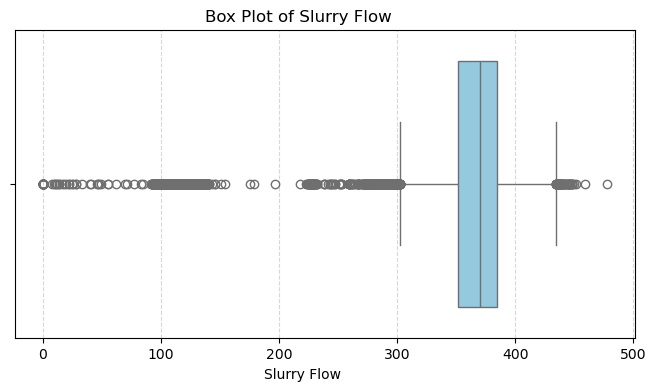

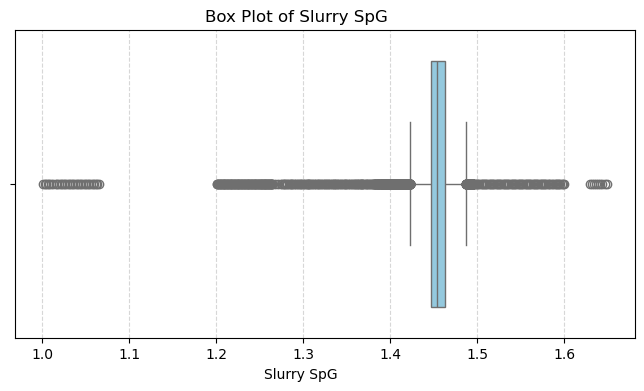

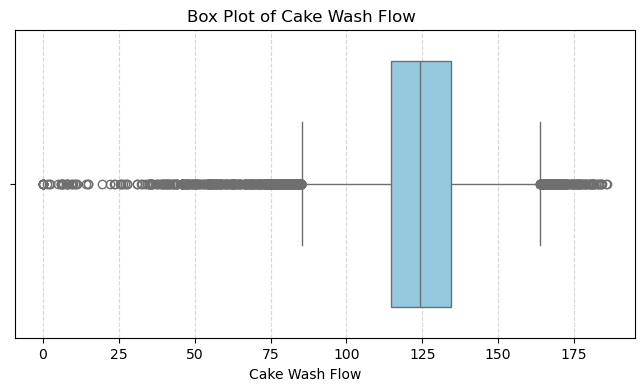

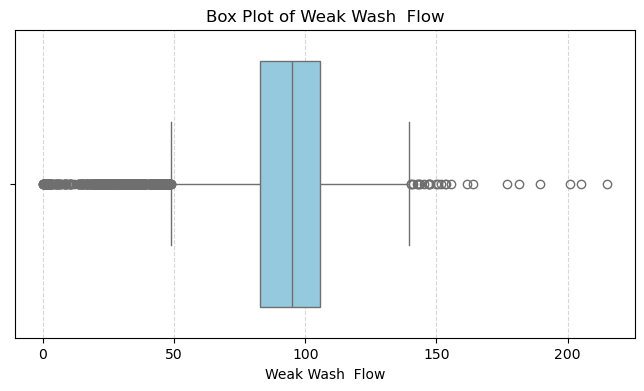

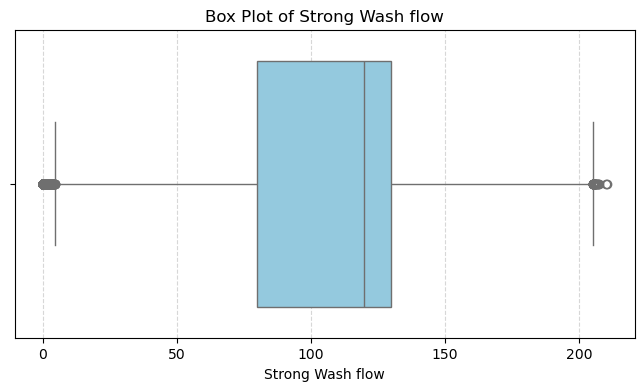

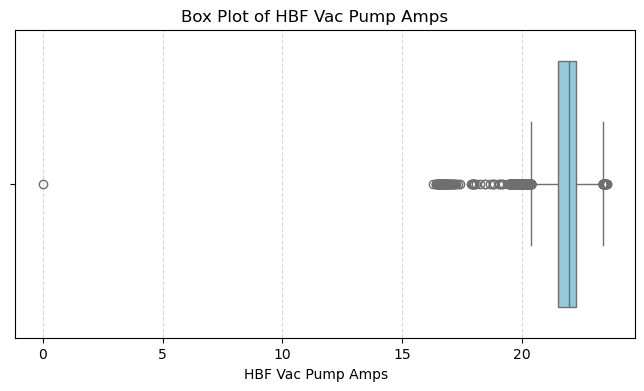

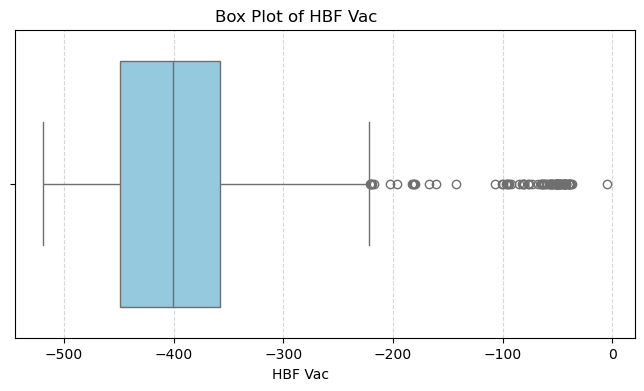

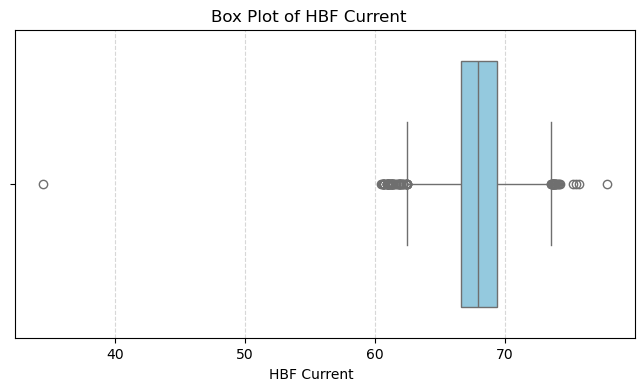

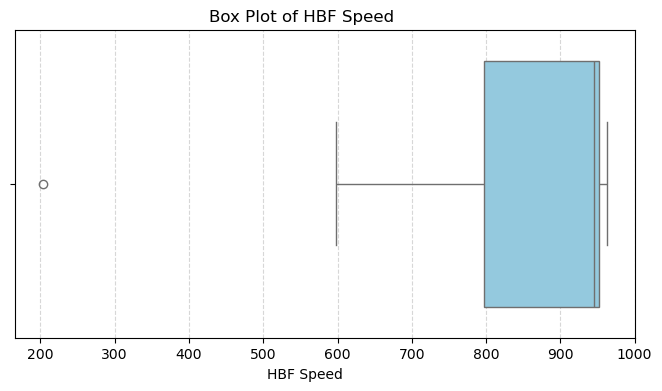

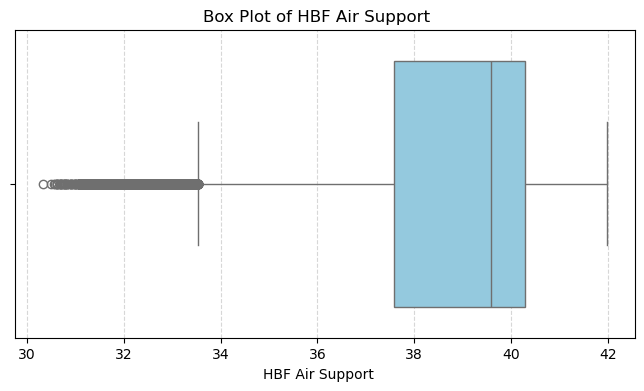

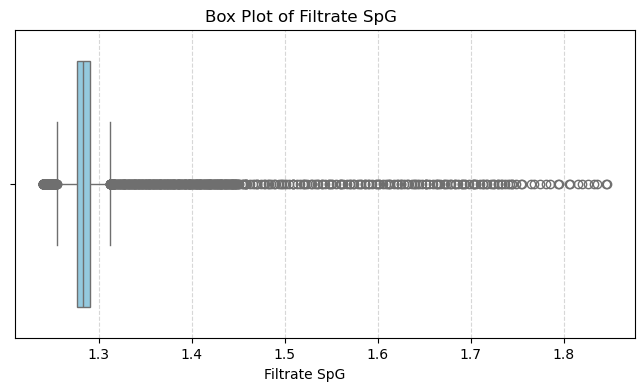

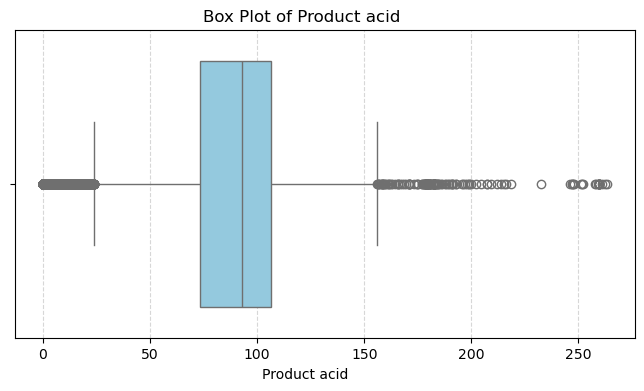

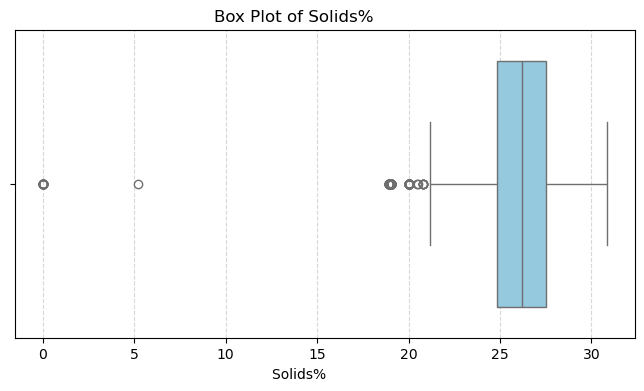

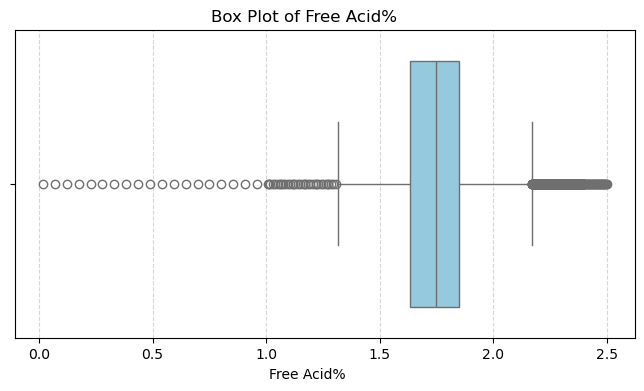

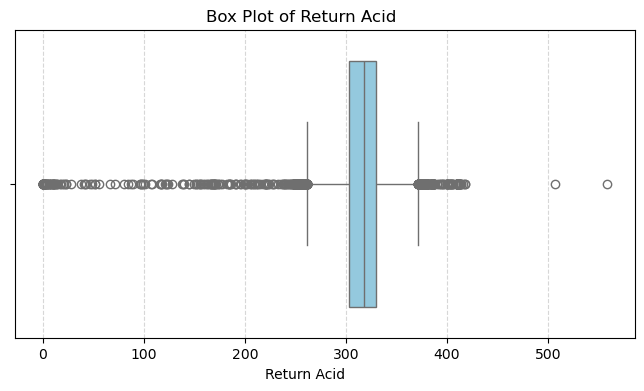

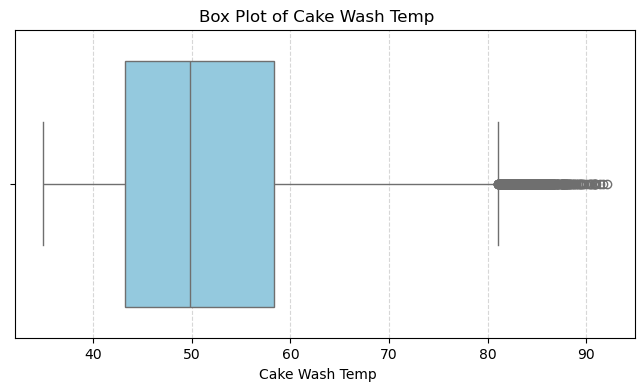

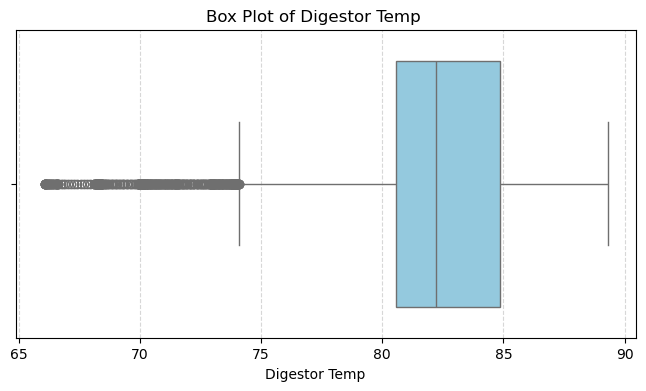

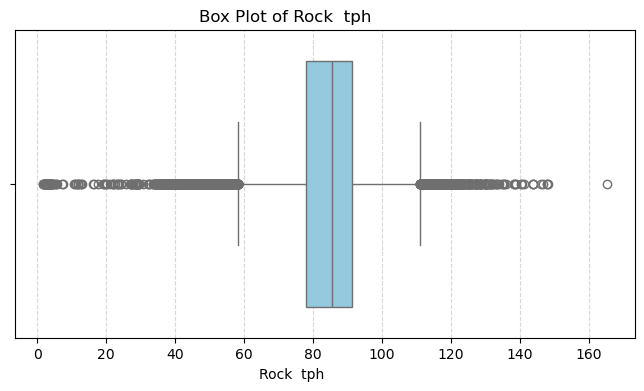

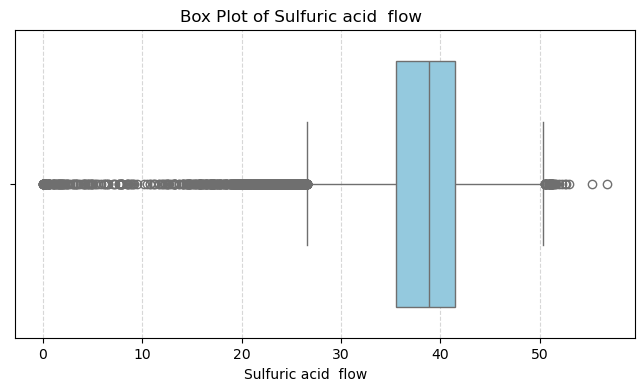

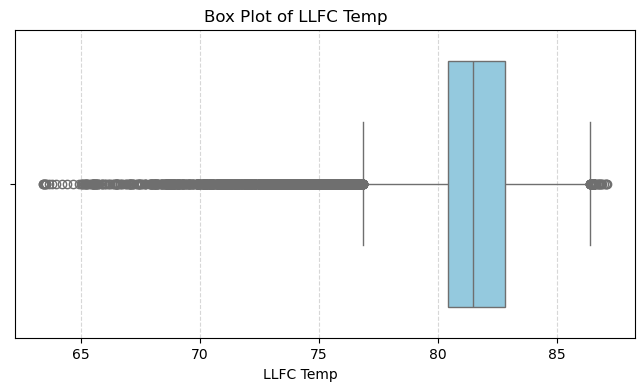

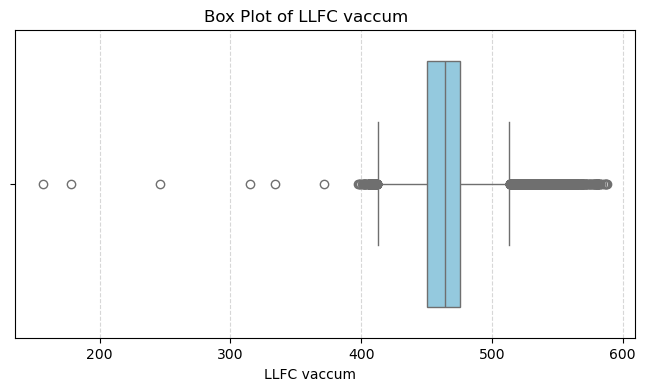

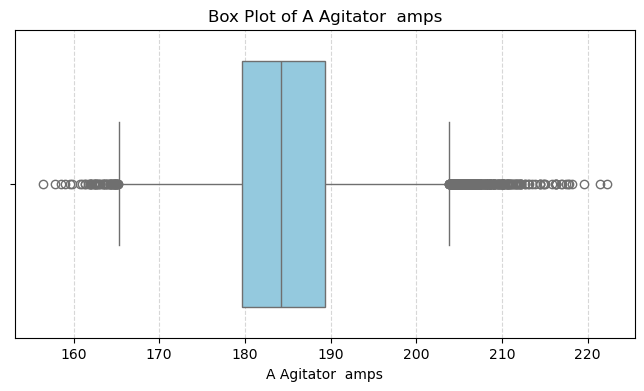

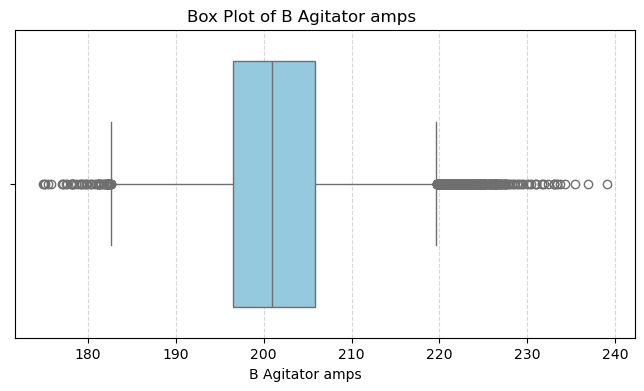

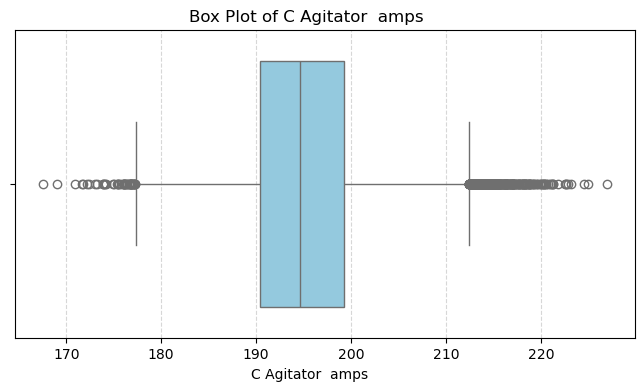

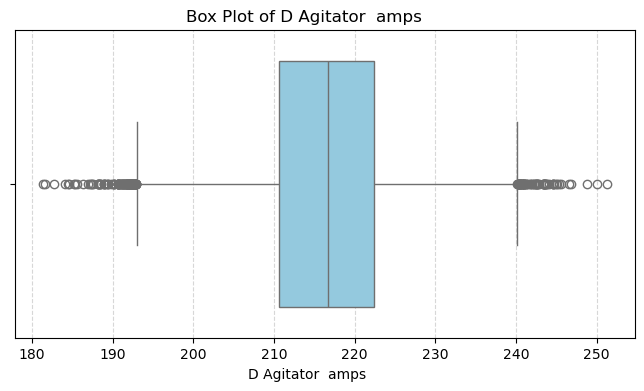

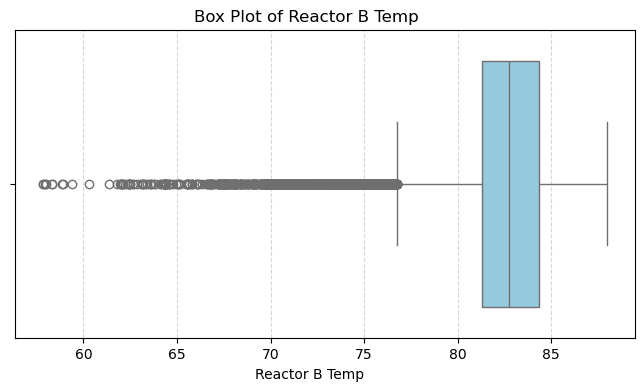

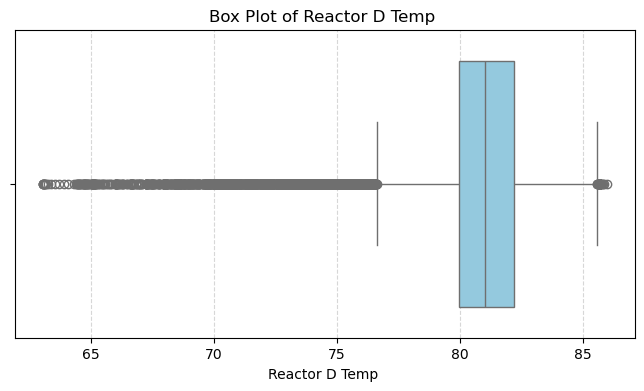

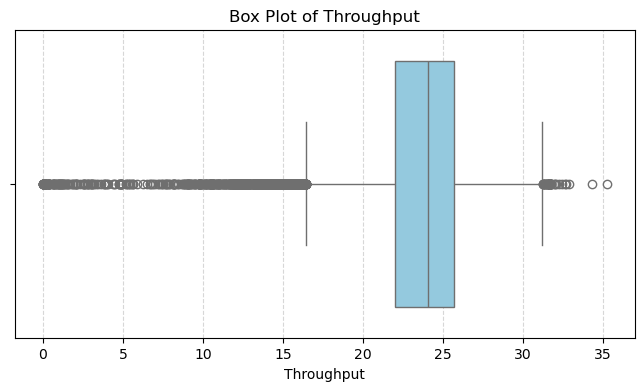

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

In [19]:
outlier_df.to_excel(
    "Outlier_Report.xlsx",
    index=False
)

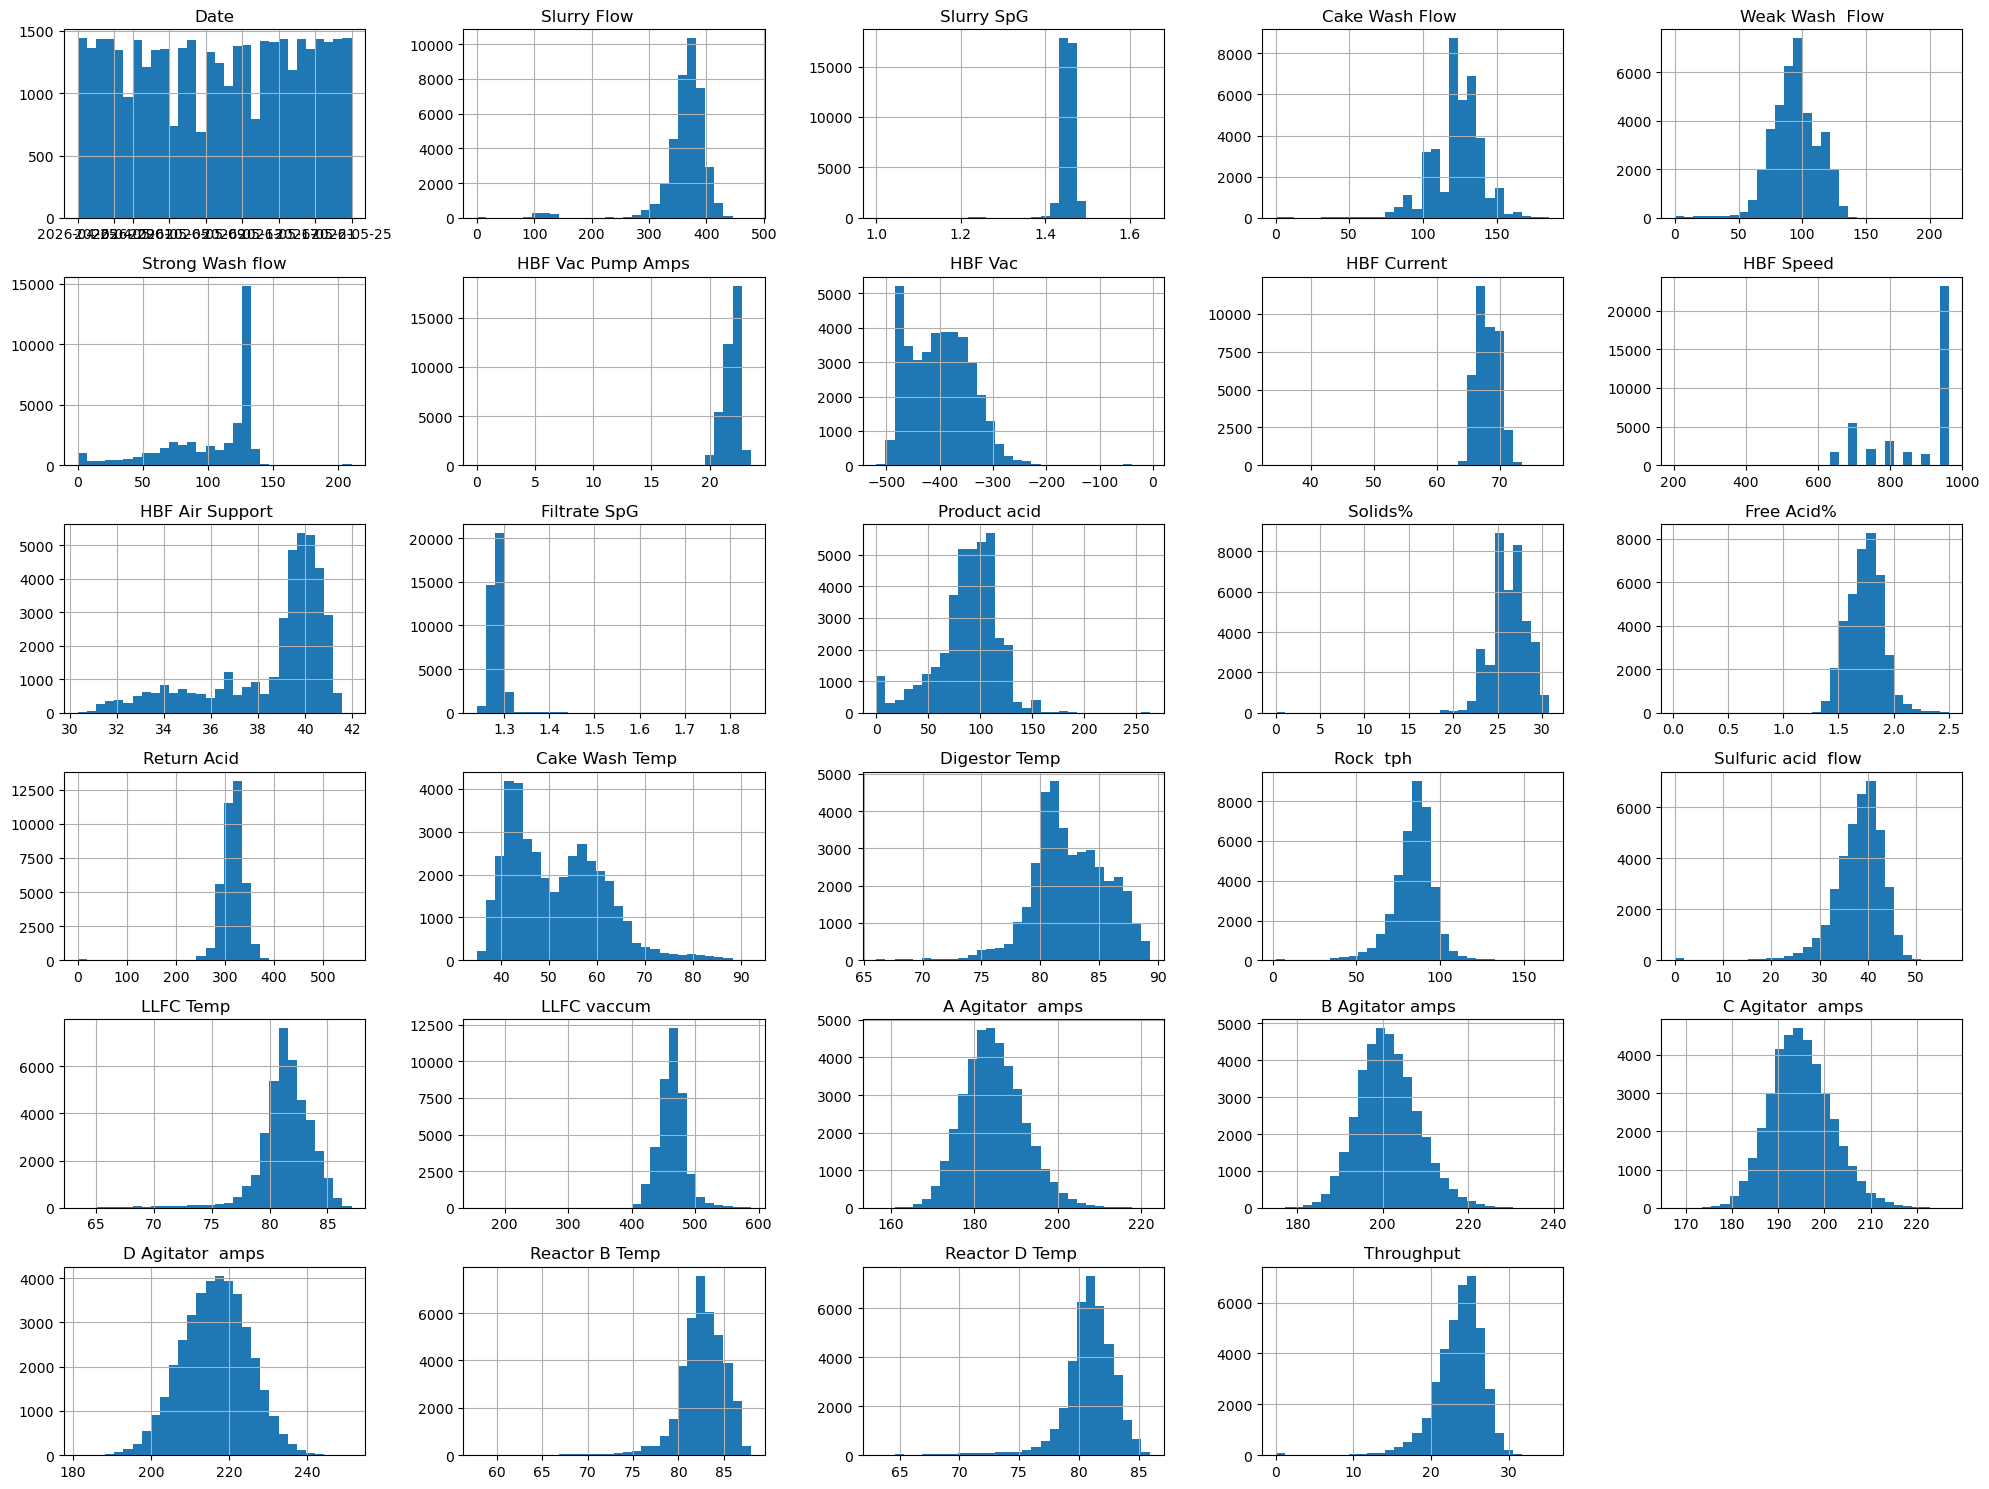

In [21]:
import matplotlib.pyplot as plt

df_clean.hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()

plt.show()

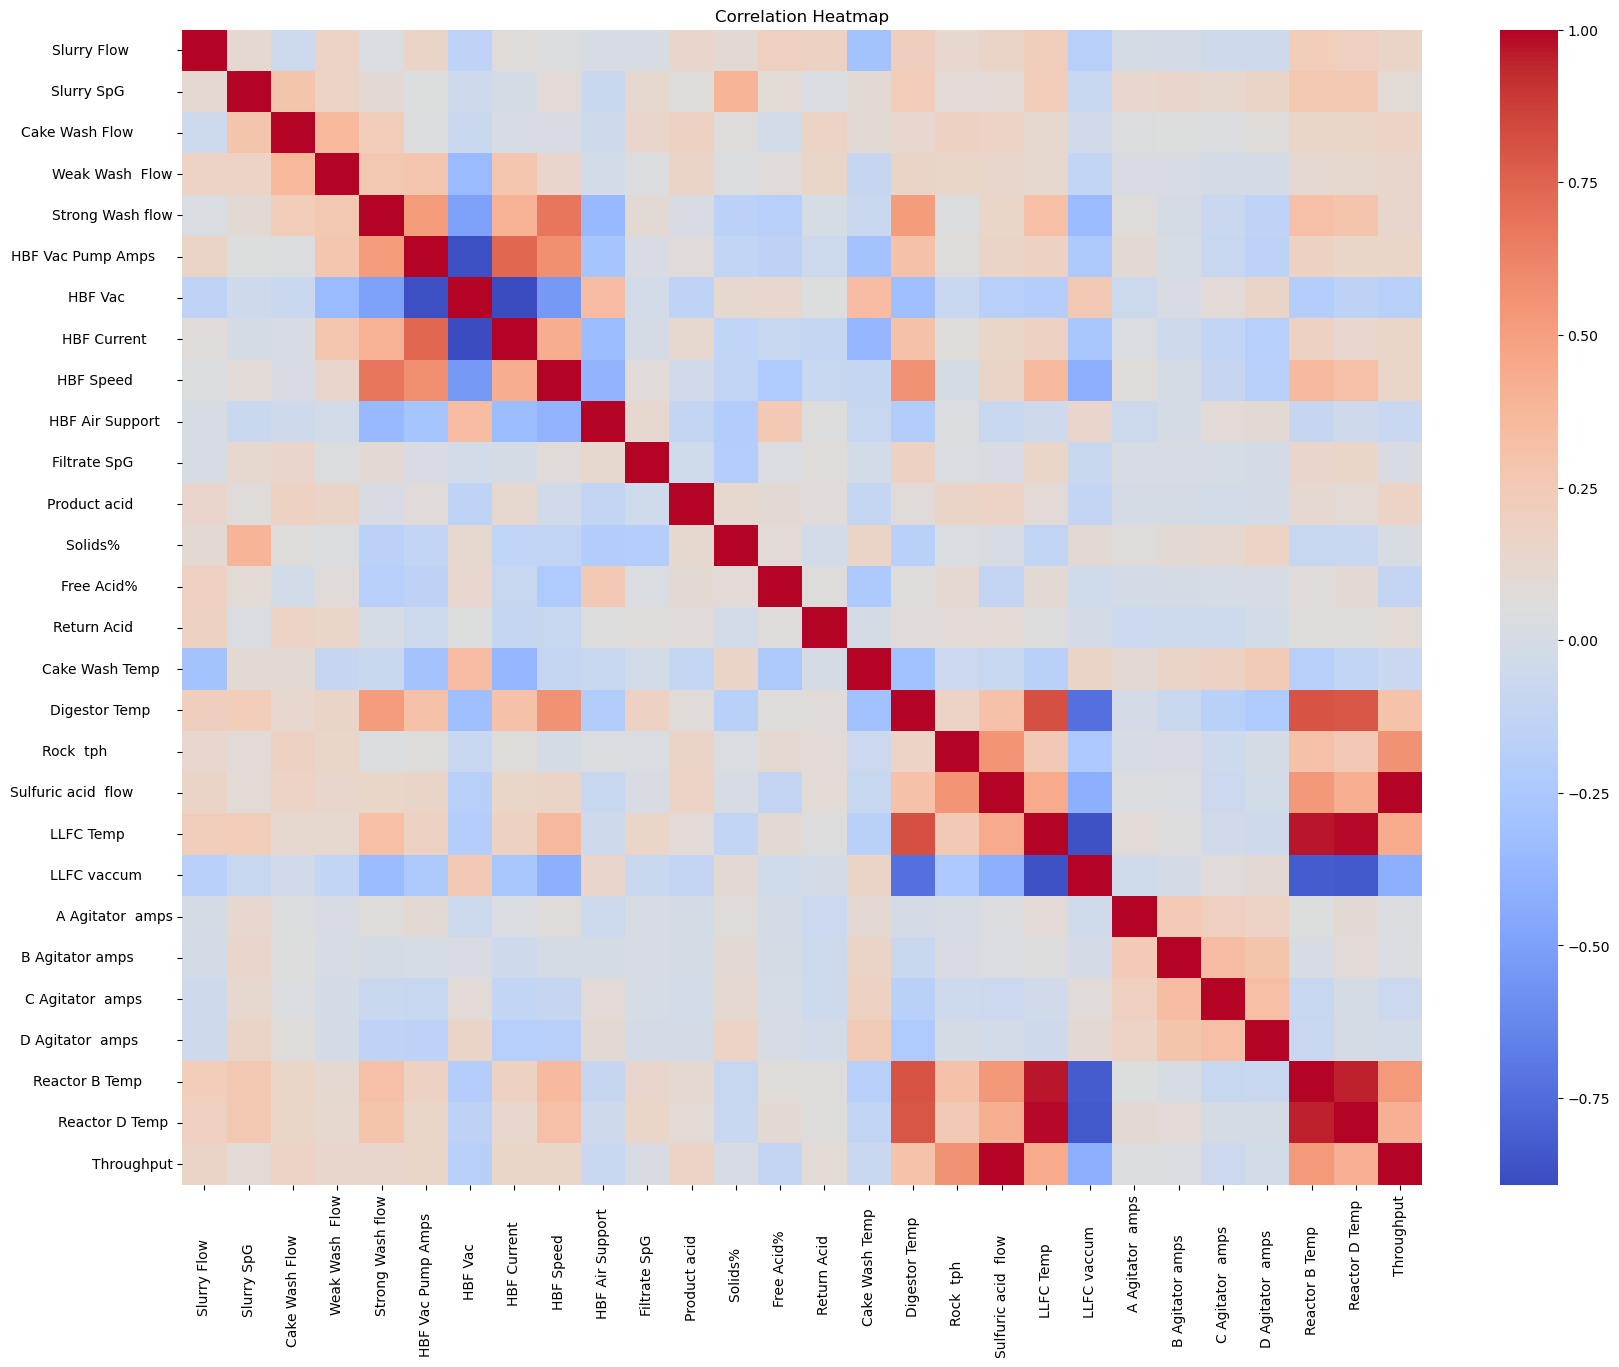

In [22]:
corr = df_clean.corr(
    numeric_only=True
)

plt.figure(figsize=(20,15))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [23]:
import pandas as pd

# Correlation matrix
corr_matrix = df_clean.corr(numeric_only=True)

# Convert to pairs
corr_pairs = corr_matrix.unstack().reset_index()

corr_pairs.columns = [
    'Column_1',
    'Column_2',
    'Correlation'
]

# Remove self correlation
corr_pairs = corr_pairs[
    corr_pairs['Column_1'] != corr_pairs['Column_2']
]

# Create unique pairs
corr_pairs['Pair'] = corr_pairs.apply(
    lambda x: tuple(
        sorted([x['Column_1'], x['Column_2']])
    ),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates('Pair')

# Positive correlations
positive_corr = corr_pairs[
    corr_pairs['Correlation'] > 0.5
].sort_values(
    by='Correlation',
    ascending=False
)

# Negative correlations
negative_corr = corr_pairs[
    corr_pairs['Correlation'] < -0.5
].sort_values(
    by='Correlation'
)

# No correlation
no_corr = corr_pairs[
    (corr_pairs['Correlation'] >= -0.1) &
    (corr_pairs['Correlation'] <= 0.1)
]

print("Positive:", positive_corr.shape)
print("Negative:", negative_corr.shape)
print("No Correlation:", no_corr.shape)

Positive: (17, 4)
Negative: (7, 4)
No Correlation: (165, 4)


In [24]:
print(positive_corr.head(10))

                         Column_1               Column_2  Correlation  \
531  Sulfuric acid  flow                      Throughput     0.999565   
558          LLFC Temp                   Reactor D Temp      0.992599   
557          LLFC Temp             Reactor B Temp            0.963443   
726         Reactor B Temp               Reactor D Temp      0.952623   
467            Digestor Temp        LLFC Temp                0.820604   
473            Digestor Temp       Reactor B Temp            0.805902   
474            Digestor Temp             Reactor D Temp      0.796721   
147         HBF Vac Pump Amps          HBF Current           0.739093   
120              Strong Wash flow     HBF Speed              0.675867   
148         HBF Vac Pump Amps         HBF Speed              0.574705   

                                              Pair  
531     (Sulfuric acid  flow         , Throughput)  
558        (LLFC Temp           , Reactor D Temp )  
557  (LLFC Temp           , Reactor B

In [25]:
print(negative_corr.head(10))

                  Column_1               Column_2  Correlation  \
175     HBF Vac                 HBF Current          -0.891703   
146  HBF Vac Pump Amps         HBF Vac               -0.873792   
552   LLFC Temp                LLFC vaccum           -0.868095   
586     LLFC vaccum               Reactor D Temp     -0.839384   
585     LLFC vaccum         Reactor B Temp           -0.822316   
468     Digestor Temp          LLFC vaccum           -0.735469   
176     HBF Vac                HBF Speed             -0.542872   

                                            Pair  
175      (HBF Current      , HBF Vac           )  
146  (HBF Vac           , HBF Vac Pump Amps    )  
552   (LLFC Temp           , LLFC vaccum       )  
586        (LLFC vaccum       , Reactor D Temp )  
585  (LLFC vaccum       , Reactor B Temp       )  
468     (Digestor Temp     , LLFC vaccum       )  
176     (HBF Speed         , HBF Vac           )  


In [26]:
print(no_corr.head(10))

                 Column_1                  Column_2  Correlation  \
2   Slurry Flow             Cake Wash Flow             -0.055316   
4   Slurry Flow                    Strong Wash flow     0.027322   
7   Slurry Flow                   HBF Current           0.073084   
8   Slurry Flow                  HBF Speed              0.044107   
9   Slurry Flow                  HBF Air Support        0.014120   
10  Slurry Flow               Filtrate SpG              0.014616   
21  Slurry Flow                    A Agitator  amps    -0.004400   
22  Slurry Flow            B Agitator amps             -0.013886   
23  Slurry Flow             C Agitator  amps           -0.044678   
24  Slurry Flow            D Agitator  amps            -0.043820   

                                                 Pair  
2    (Cake Wash Flow         , Slurry Flow          )  
4           (Slurry Flow          , Strong Wash flow)  
7          (HBF Current      , Slurry Flow          )  
8         (HBF Speed       

In [27]:
with pd.ExcelWriter(
    "Correlation_Report.xlsx"
) as writer:

    positive_corr.to_excel(
        writer,
        sheet_name="Positive",
        index=False
    )

    negative_corr.to_excel(
        writer,
        sheet_name="Negative",
        index=False
    )

    no_corr.to_excel(
        writer,
        sheet_name="No_Correlation",
        index=False
    )

In [28]:
print("\nTop 10 Positive Correlations")
print(
    positive_corr[
        ['Column_1','Column_2','Correlation']
    ].head(10)
)

print("\nTop 10 Negative Correlations")
print(
    negative_corr[
        ['Column_1','Column_2','Correlation']
    ].head(10)
)


Top 10 Positive Correlations
                         Column_1               Column_2  Correlation
531  Sulfuric acid  flow                      Throughput     0.999565
558          LLFC Temp                   Reactor D Temp      0.992599
557          LLFC Temp             Reactor B Temp            0.963443
726         Reactor B Temp               Reactor D Temp      0.952623
467            Digestor Temp        LLFC Temp                0.820604
473            Digestor Temp       Reactor B Temp            0.805902
474            Digestor Temp             Reactor D Temp      0.796721
147         HBF Vac Pump Amps          HBF Current           0.739093
120              Strong Wash flow     HBF Speed              0.675867
148         HBF Vac Pump Amps         HBF Speed              0.574705

Top 10 Negative Correlations
                  Column_1               Column_2  Correlation
175     HBF Vac                 HBF Current          -0.891703
146  HBF Vac Pump Amps         HBF Vac      

In [29]:
df.columns

Index(['Date', 'Slurry Flow          ', 'Slurry SpG           ',
       'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow',
       'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ',
       'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ',
       'Product acid         ', 'Solids%            ', 'Free Acid%        ',
       'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ',
       'Rock  tph               ', 'Sulfuric acid  flow         ',
       'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps',
       'B Agitator amps         ', 'C Agitator  amps       ',
       'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ',
       'Throughput'],
      dtype='object')

In [30]:
features = [
    'Slurry Flow',
    'Slurry SpG',
    'Cake Wash Flow',
    'Weak Wash Flow',
    'Strong Wash flow',
    'HBF Vac Pump Amps',
    'HBF Vac',
    'HBF Current',
    'HBF Speed',
    'HBF Air Support',
    'Filtrate SpG',
    'Product acid',
    'Solids%',
    'Return Acid',
    'Cake Wash Temp',
    'Digester Temp',
    'Rock tph',
    'Sulfuric acid flow',
    'LLFC Temp',
    'LLFC vaccum',
    'A Agitator amps',
    'B Agitator amps',
    'C Agitator amps',
    'D Agitator amps',
    'Reactor B Temp',
    'Reactor D Temp',
    'Throughput'
]

target = 'Free Acid%'

In [34]:
print(df.columns)

Index(['Date', 'Slurry Flow          ', 'Slurry SpG           ',
       'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow',
       'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ',
       'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ',
       'Product acid         ', 'Solids%            ', 'Free Acid%        ',
       'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ',
       'Rock  tph               ', 'Sulfuric acid  flow         ',
       'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps',
       'B Agitator amps         ', 'C Agitator  amps       ',
       'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ',
       'Throughput'],
      dtype='object')


In [35]:
print(df_clean.columns)

Index(['Date', 'Slurry Flow          ', 'Slurry SpG           ',
       'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow',
       'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ',
       'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ',
       'Product acid         ', 'Solids%            ', 'Free Acid%        ',
       'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ',
       'Rock  tph               ', 'Sulfuric acid  flow         ',
       'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps',
       'B Agitator amps         ', 'C Agitator  amps       ',
       'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ',
       'Throughput'],
      dtype='object')


In [36]:
print(df_clean.columns.tolist())

['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']


In [37]:
missing = [col for col in features if col not in df_clean.columns]

print("Missing Columns:")
print(missing)

Missing Columns:
['Slurry Flow', 'Slurry SpG', 'Cake Wash Flow', 'Weak Wash Flow', 'HBF Vac Pump Amps', 'HBF Vac', 'HBF Current', 'HBF Speed', 'HBF Air Support', 'Filtrate SpG', 'Product acid', 'Solids%', 'Return Acid', 'Cake Wash Temp', 'Digester Temp', 'Rock tph', 'Sulfuric acid flow', 'LLFC Temp', 'LLFC vaccum', 'A Agitator amps', 'B Agitator amps', 'C Agitator amps', 'D Agitator amps', 'Reactor B Temp', 'Reactor D Temp']


In [38]:
missing = [col for col in features if col not in df.columns]

print(missing)

['Slurry Flow', 'Slurry SpG', 'Cake Wash Flow', 'Weak Wash Flow', 'HBF Vac Pump Amps', 'HBF Vac', 'HBF Current', 'HBF Speed', 'HBF Air Support', 'Filtrate SpG', 'Product acid', 'Solids%', 'Return Acid', 'Cake Wash Temp', 'Digester Temp', 'Rock tph', 'Sulfuric acid flow', 'LLFC Temp', 'LLFC vaccum', 'A Agitator amps', 'B Agitator amps', 'C Agitator amps', 'D Agitator amps', 'Reactor B Temp', 'Reactor D Temp']


In [39]:
print(type(df_clean))

<class 'pandas.core.frame.DataFrame'>


In [40]:
print(df_clean.shape)

(38736, 29)


In [41]:
print(df_clean.columns.tolist())

['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']


In [42]:
print(df_clean.columns.tolist())

['Date', 'Slurry Flow          ', 'Slurry SpG           ', 'Cake Wash Flow         ', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps    ', 'HBF Vac           ', 'HBF Current      ', 'HBF Speed         ', 'HBF Air Support   ', 'Filtrate SpG         ', 'Product acid         ', 'Solids%            ', 'Free Acid%        ', 'Return Acid         ', 'Cake Wash Temp   ', 'Digestor Temp     ', 'Rock  tph               ', 'Sulfuric acid  flow         ', 'LLFC Temp           ', 'LLFC vaccum       ', 'A Agitator  amps', 'B Agitator amps         ', 'C Agitator  amps       ', 'D Agitator  amps        ', 'Reactor B Temp       ', 'Reactor D Temp ', 'Throughput']


In [43]:
# Remove leading and trailing spaces from all column names
df_clean.columns = df_clean.columns.str.strip()

# Verify the cleaned column names
print(df_clean.columns.tolist())

['Date', 'Slurry Flow', 'Slurry SpG', 'Cake Wash Flow', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps', 'HBF Vac', 'HBF Current', 'HBF Speed', 'HBF Air Support', 'Filtrate SpG', 'Product acid', 'Solids%', 'Free Acid%', 'Return Acid', 'Cake Wash Temp', 'Digestor Temp', 'Rock  tph', 'Sulfuric acid  flow', 'LLFC Temp', 'LLFC vaccum', 'A Agitator  amps', 'B Agitator amps', 'C Agitator  amps', 'D Agitator  amps', 'Reactor B Temp', 'Reactor D Temp', 'Throughput']


In [44]:
print(df_clean.columns.tolist())

['Date', 'Slurry Flow', 'Slurry SpG', 'Cake Wash Flow', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps', 'HBF Vac', 'HBF Current', 'HBF Speed', 'HBF Air Support', 'Filtrate SpG', 'Product acid', 'Solids%', 'Free Acid%', 'Return Acid', 'Cake Wash Temp', 'Digestor Temp', 'Rock  tph', 'Sulfuric acid  flow', 'LLFC Temp', 'LLFC vaccum', 'A Agitator  amps', 'B Agitator amps', 'C Agitator  amps', 'D Agitator  amps', 'Reactor B Temp', 'Reactor D Temp', 'Throughput']


In [45]:
target = 'Free Acid%'

features = df_clean.columns.drop(['Date', target]).tolist()

print(features)
print("Number of Features:", len(features))

['Slurry Flow', 'Slurry SpG', 'Cake Wash Flow', 'Weak Wash  Flow', 'Strong Wash flow', 'HBF Vac Pump Amps', 'HBF Vac', 'HBF Current', 'HBF Speed', 'HBF Air Support', 'Filtrate SpG', 'Product acid', 'Solids%', 'Return Acid', 'Cake Wash Temp', 'Digestor Temp', 'Rock  tph', 'Sulfuric acid  flow', 'LLFC Temp', 'LLFC vaccum', 'A Agitator  amps', 'B Agitator amps', 'C Agitator  amps', 'D Agitator  amps', 'Reactor B Temp', 'Reactor D Temp', 'Throughput']
Number of Features: 27


In [46]:
X = df_clean[features]
y = df_clean[target]

In [47]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (38736, 27)
y Shape: (38736,)


In [48]:
# Remove leading/trailing spaces and replace multiple spaces with a single space
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

print(df_clean.columns.tolist())

['Date', 'Slurry Flow', 'Slurry SpG', 'Cake Wash Flow', 'Weak Wash Flow', 'Strong Wash flow', 'HBF Vac Pump Amps', 'HBF Vac', 'HBF Current', 'HBF Speed', 'HBF Air Support', 'Filtrate SpG', 'Product acid', 'Solids%', 'Free Acid%', 'Return Acid', 'Cake Wash Temp', 'Digestor Temp', 'Rock tph', 'Sulfuric acid flow', 'LLFC Temp', 'LLFC vaccum', 'A Agitator amps', 'B Agitator amps', 'C Agitator amps', 'D Agitator amps', 'Reactor B Temp', 'Reactor D Temp', 'Throughput']


In [49]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(y.values.reshape(-1,1))

In [50]:
print(X_scaled.shape)
print(y_scaled.shape)

print(X_scaled[:2])
print(y_scaled[:2])

(38736, 27)
(38736, 1)
[[0.73802977 0.6872569  0.72591497 0.52610677 0.46145841 0.90772808
  0.28318679 0.7849499  0.58530326 0.87485643 0.08080678 0.42332417
  0.85041636 0.57198413 0.24995729 0.56118681 0.01413662 0.23236826
  0.59879577 0.82723129 0.44921227 0.43574442 0.39886384 0.56007859
  0.63785302 0.64196934 0.23236826]
 [0.75414887 0.68721797 0.73211835 0.48922734 0.44506111 0.8845187
  0.36739266 0.75031759 0.58552617 0.88025638 0.08062066 0.41438848
  0.85041636 0.57412393 0.25272128 0.55840929 0.12460899 0.18931997
  0.59112928 0.83262979 0.40301122 0.54794816 0.47015176 0.54724147
  0.63194714 0.63551334 0.18931997]]
[[0.788569  ]
 [0.78783905]]


In [51]:
import numpy as np

time_steps = 10

X_seq = []
y_seq = []

for i in range(time_steps, len(X_scaled)):
    
    X_seq.append(X_scaled[i-time_steps:i])
    
    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [52]:
print(X_seq.shape)
print(y_seq.shape)

(38726, 10, 27)
(38726, 1)


In [53]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [54]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (30980, 10, 27)
X_test : (7746, 10, 27)
y_train: (30980, 1)
y_test : (7746, 1)


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [57]:
model = Sequential()

In [58]:
model.add(
    SimpleRNN(
        units=64,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

c:\Users\Dr Mutyala Balaji\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
model.add(Dropout(0.2))

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential()

model.add(
    SimpleRNN(
        units=64,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

In [61]:
model.add(Dense(1))

In [62]:
Dense(3)

<Dense name=dense_1, built=False>

In [63]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [64]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,953 (23.25 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0288 - mae: 0.1146 - val_loss: 0.0032 - val_mae: 0.0441
Epoch 2/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0078 - mae: 0.0688 - val_loss: 0.0032 - val_mae: 0.0456
Epoch 3/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0061 - mae: 0.0606 - val_loss: 0.0034 - val_mae: 0.0480
Epoch 4/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0049 - mae: 0.0545 - val_loss: 0.0034 - val_mae: 0.0481
Epoch 5/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0043 - mae: 0.0507 - val_loss: 0.0114 - val_mae: 0.0950
Epoch 6/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0039 - mae: 0.0478 - val_loss: 0.0028 - val_mae: 0.0429
Epoch 7/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0035 - mae: 0.0454 - val_loss: 0.0038 - val_mae: 0.0509
Epoch 8/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0033 - mae: 0.0438 - val_loss: 0.0029 - val_mae: 0.0438
Epoch 9/30
969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - l

In [66]:
y_pred = model.predict(X_test)

243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [68]:
y_pred = model.predict(X_test)

243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [70]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(
    y.values.reshape(-1,1)
)

In [71]:
time_steps = 10

X_seq = []
y_seq = []

for i in range(time_steps, len(X_scaled)):
    X_seq.append(X_scaled[i-time_steps:i])
    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(len(X_seq)*0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [72]:
y_pred = model.predict(X_test)

y_pred_actual = target_scaler.inverse_transform(y_pred)

y_test_actual = target_scaler.inverse_transform(y_test)

243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

print("="*40)
print("RNN Model Performance")
print("="*40)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                 : {r2:.4f}")

RNN Model Performance
Mean Absolute Error (MAE) : 0.1634
Mean Squared Error (MSE)  : 0.0404
Root Mean Squared Error   : 0.2009
R² Score                 : -1.0885


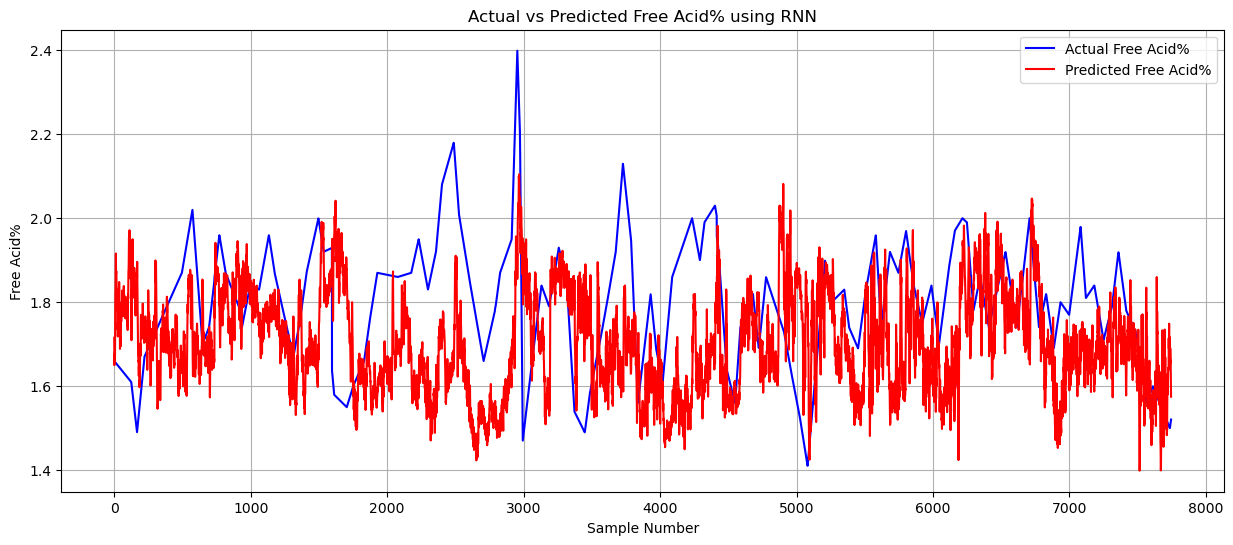

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test_actual, color='blue', label='Actual Free Acid%')
plt.plot(y_pred_actual, color='red', label='Predicted Free Acid%')

plt.title("Actual vs Predicted Free Acid% using RNN")

plt.xlabel("Sample Number")
plt.ylabel("Free Acid%")

plt.legend()
plt.grid(True)

plt.show()

In [1]:
from sklearn.metrics import r2_score

# Training predictions
y_train_pred = model.predict(X_train)

# Convert back to original scale
y_train_pred_actual = target_scaler.inverse_transform(y_train_pred)
y_train_actual = target_scaler.inverse_transform(y_train)

# Training R²
train_r2 = r2_score(y_train_actual, y_train_pred_actual)

# Testing R²
test_r2 = r2_score(y_test_actual, y_pred_actual)

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")

print(f"Train Accuracy : {train_r2*100:.2f}%")
print(f"Test Accuracy  : {test_r2*100:.2f}%")

NameError: name 'model' is not defined

In [76]:
print("Final Training MAE :", history.history['mae'][-1])
print("Final Validation MAE :", history.history['val_mae'][-1])

print("Final Training Loss :", history.history['loss'][-1])
print("Final Validation Loss :", history.history['val_loss'][-1])

Final Training MAE : 0.03298930451273918
Final Validation MAE : 0.0658554807305336
Final Training Loss : 0.0019548104610294104
Final Validation Loss : 0.006556172389537096


In [77]:
print("R² Score:", r2)

R² Score: -1.0885094779557294


In [78]:
print(y_pred.shape)
print(y_test.shape)

print(y_pred_actual.shape)
print(y_test_actual.shape)

(7746, 1)
(7746, 1)
(7746, 1)
(7746, 1)


In [79]:
print("Actual")
print(y_test_actual[:10])

print("Predicted")
print(y_pred_actual[:10])

Actual
[[1.66003071]
 [1.65962896]
 [1.65922721]
 [1.65882546]
 [1.65842371]
 [1.65802196]
 [1.65762021]
 [1.65721846]
 [1.65681671]
 [1.65641496]]
Predicted
[[1.7156212]
 [1.6501431]
 [1.6758696]
 [1.6663712]
 [1.6650919]
 [1.6573911]
 [1.6964614]
 [1.784127 ]
 [1.8204988]
 [1.8305063]]


In [80]:
from sklearn.metrics import r2_score

print(r2_score(y_test_actual.flatten(),
               y_pred_actual.flatten()))

-1.0885094779557294


In [81]:
print(y_pred_actual[:5])

print(y_test_actual[:5])

print(y_pred_actual.shape)

print(y_test_actual.shape)

[[1.7156212]
 [1.6501431]
 [1.6758696]
 [1.6663712]
 [1.6650919]]
[[1.66003071]
 [1.65962896]
 [1.65922721]
 [1.65882546]
 [1.65842371]]
(7746, 1)
(7746, 1)


In [82]:
results = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": y_pred_actual.flatten()
})

print(results.head(10))

     Actual  Predicted
0  1.660031   1.715621
1  1.659629   1.650143
2  1.659227   1.675870
3  1.658825   1.666371
4  1.658424   1.665092
5  1.658022   1.657391
6  1.657620   1.696461
7  1.657218   1.784127
8  1.656817   1.820499
9  1.656415   1.830506


In [83]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test_actual.flatten(),
    y_pred_actual.flatten()
)

print("R² Score:", r2)

R² Score: -1.0885094779557294


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test_actual.flatten(),
    y_pred_actual.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual.flatten(),
        y_pred_actual.flatten()
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 0.16341399435344717
RMSE: 0.20091965897506534


In [85]:
print("Minimum:", y_test_actual.min())
print("Maximum:", y_test_actual.max())
print("Mean:", y_test_actual.mean())
print("Standard Deviation:", y_test_actual.std())

Minimum: 1.4106311327348522
Maximum: 2.398734847879108
Mean: 1.7989854892696664
Standard Deviation: 0.13902861844176995


In [86]:
print(results.describe())

            Actual    Predicted
count  7746.000000  7746.000000
mean      1.798985     1.703341
std       0.139038     0.116704
min       1.410631     1.398868
25%       1.718685     1.616640
50%       1.809293     1.695850
75%       1.886560     1.787618
max       2.398735     2.104475


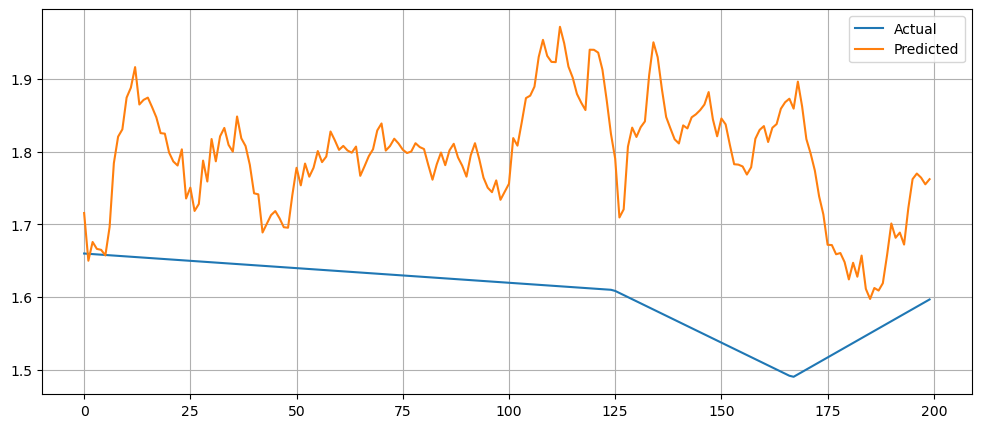

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(results["Actual"][:200], label="Actual")
plt.plot(results["Predicted"][:200], label="Predicted")
plt.legend()
plt.grid(True)
plt.show()